In [1]:
from src.Elements import Elements
from torchview import draw_graph
import graphviz 
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from src.models import VisionTransformer
input_size = 4096
patch_size = 16
embed_dim = 16 
num_heads = 4
num_classes = len(Elements.LINES) 
num_layers = 6
hidden_dim = 4 * embed_dim
dropout_rate = 0.1

model = VisionTransformer(input_size, patch_size, embed_dim, num_heads, num_classes, num_layers, hidden_dim, dropout_rate).to(device)

model.to(device)

pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

print(model)


torch.Size([16])
89616
VisionTransformer(
  (patch_embed): Conv1d(1, 16, kernel_size=(16,), stride=(16,), bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
      )
      (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (feedforward): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=16, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=4096, out_features=16, bias=True)
  (gelu): GELU(approximate='none')
  (sigmoid): Sigmoid()
)


In [4]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/semi_artifficial/X.npy")
y = np.load("data/semi_artifficial/y.npy")
y[y>0] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 256)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 256)


In [5]:
from pathlib import Path
from datetime import datetime 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# class CustomLoss(nn.Module):
#     def __init__(self, alpha=0.01):
#         super(CustomLoss, self).__init__()
#         self.alpha = alpha
#         self.mse_criterion = nn.L1Loss()
#         self.bce_criterion = nn.BCELoss()

#     def forward(self, y_pred, x_pred , y_batch, X_batch):
#         x_loss = self.mse_criterion(x_pred, X_batch) * (1 - self.alpha) 
#         y_batch[y_batch > 0] = 1
#         y_loss = self.bce_criterion(y_pred, y_batch) * self.alpha
#         return y_loss + x_loss, x_loss, y_loss
        
# custom_criterion = CustomLoss(0.5)


# train_history, valid_history, best_loss, best_weights = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=custom_criterion, epochs=300, mode="constrained_autoencoder", patience=25)

criterion = nn.MSELoss()
train_history, valid_history, best_loss, best_weights, f1_scores, accuracies, recalls, precisions = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=10, mode="supervised", patience=5)


2025-04-11 22:43:31,164 - Epoch 1/10 started.
2025-04-11 22:44:55,301 - Train Epoch Average Loss: 0.0493
2025-04-11 22:44:57,503 - Validation Loss: 0.0298
/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025-04-11 22:44:57,654 - 
Accuracy       : [==============           ] 0.5753
Precision      : [======================== ] 0.9758
Recall         : [======================   ] 0.8855
F1 Score       : [======================   ] 0.9176
2025-04-11 22:44:57,660 - New best model saved.
2025-04-11 22:44:57,660 - Epoch 1 finished in 86.50 seconds.

2025-04-11 22:44:57,661 - Epoch 2/10 started.
2025-04-11 22:45:55,353 - Train Epoch Average Loss: 0.0285
2025-04-11 22:45:57,514 - Validation Loss: 0.0268
/ho

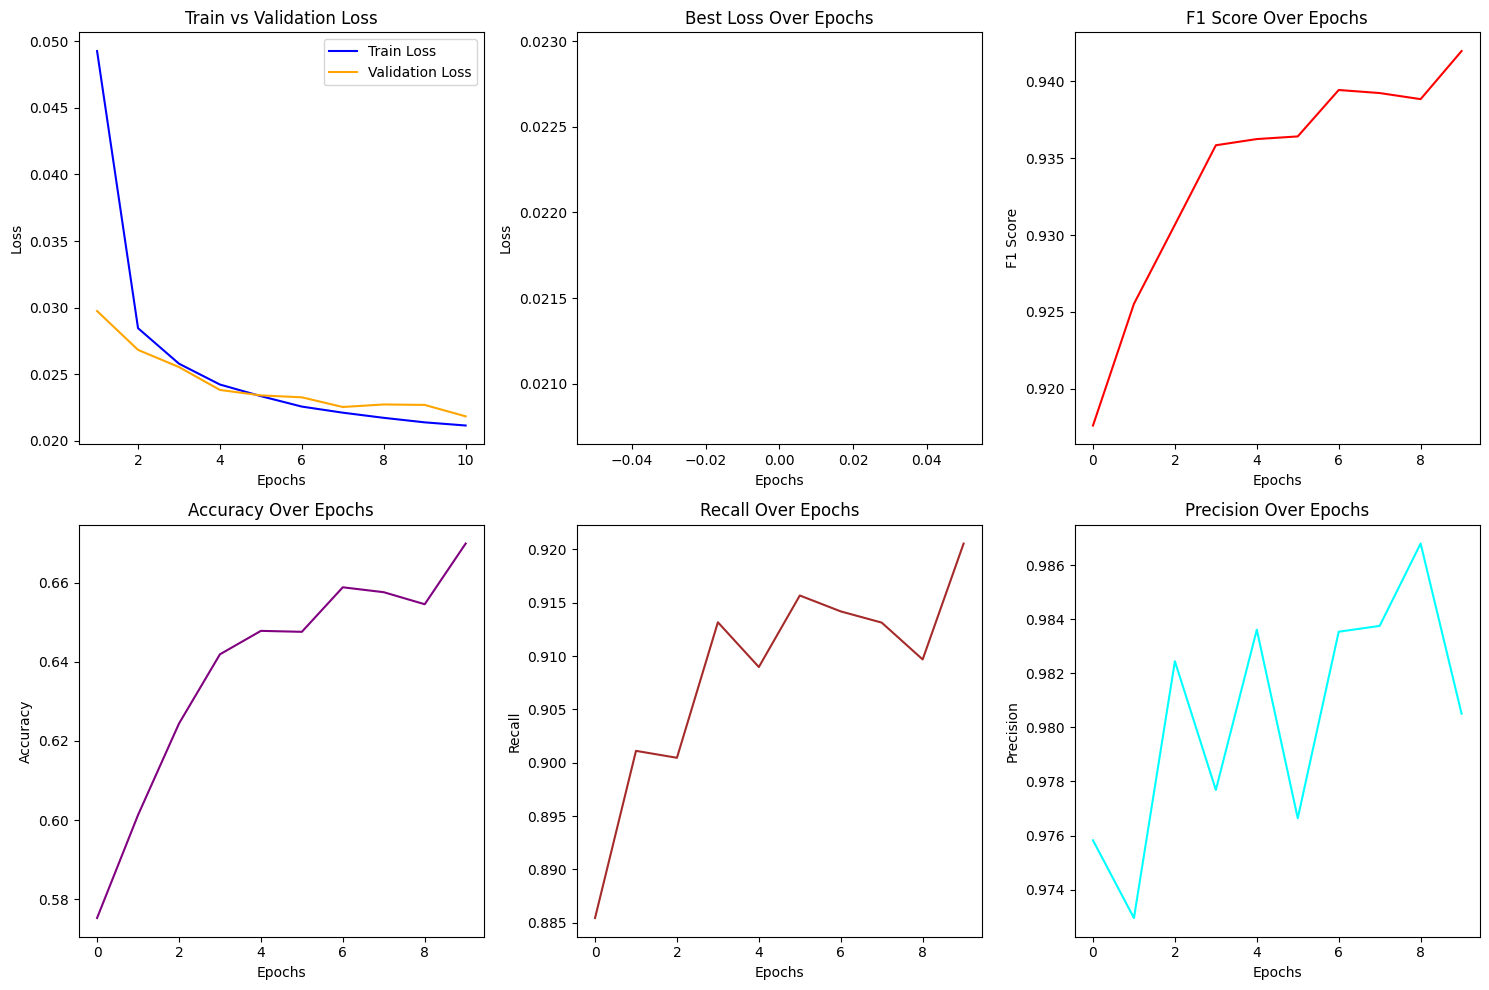

In [7]:
import matplotlib.pyplot as plt 
# Assuming these are lists or arrays representing the values over epochs
epochs = range(1, len(train_history) + 1)  # Assuming length of train_history gives number of epochs

# Create a figure and axes to hold subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Plot Train and Validation Loss
axs[0, 0].plot(epochs, train_history, label="Train Loss", color="blue")
axs[0, 0].plot(epochs, valid_history, label="Validation Loss", color="orange")
axs[0, 0].set_title("Train vs Validation Loss")
axs[0, 0].set_xlabel("Epochs")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].legend()

# Plot Best Loss
axs[0, 1].plot(best_loss, label="Best Loss", color="green")
axs[0, 1].set_title("Best Loss Over Epochs")
axs[0, 1].set_xlabel("Epochs")
axs[0, 1].set_ylabel("Loss")

# Plot F1 Scores
axs[0, 2].plot(f1_scores, label="F1 Score", color="red")
axs[0, 2].set_title("F1 Score Over Epochs")
axs[0, 2].set_xlabel("Epochs")
axs[0, 2].set_ylabel("F1 Score")

# Plot Accuracy
axs[1, 0].plot(accuracies, label="Accuracy", color="purple")
axs[1, 0].set_title("Accuracy Over Epochs")
axs[1, 0].set_xlabel("Epochs")
axs[1, 0].set_ylabel("Accuracy")

# Plot Recall
axs[1, 1].plot(recalls, label="Recall", color="brown")
axs[1, 1].set_title("Recall Over Epochs")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].set_ylabel("Recall")

# Plot Precision
axs[1, 2].plot(precisions, label="Precision", color="cyan")
axs[1, 2].set_title("Precision Over Epochs")
axs[1, 2].set_xlabel("Epochs")
axs[1, 2].set_ylabel("Precision")

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()


In [ ]:
MODEL_NAME = model.__class__.__name__
torch.save(model.state_dict(), Path(f"data/model_weights/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}"))

VisionTransformer


In [ ]:
aucs, rocs = EvaluationUtils.calculate_roc(model, testloader)

Average AUC: 0.9807


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

def calculate_roc(model, test_loader):
    model.eval()
    all_real, all_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            all_real.append(y_batch.cpu())
            all_pred.append(y_pred.cpu())

    all_real = torch.cat(all_real).numpy()
    all_pred = torch.cat(all_pred).numpy()
    n_classes = all_real.shape[1]
    aucs = {}
    rocs = {}

    for i in range(n_classes):
        symbol = Elements.NUM2SYMBOL[i]
        fpr, tpr, _ = roc_curve(all_real[:, i], all_pred[:, i])
        roc_auc = auc(fpr, tpr)
        aucs[symbol] = roc_auc
        rocs[symbol] = (fpr, tpr)

    return aucs, rocs

aucs, rocs = calculate_roc(model, testloader)

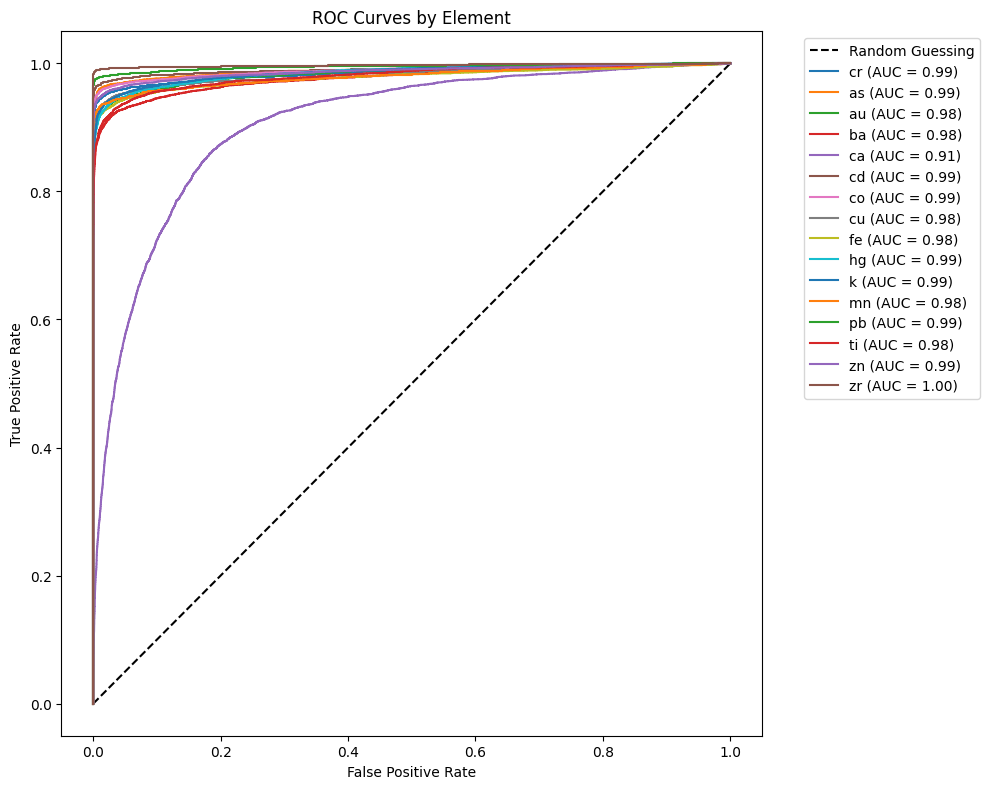

In [16]:


plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
for element_name in Elements.LINES.keys():
    plt.plot(*rocs[element_name], label=f"{element_name} (AUC = {aucs[element_name]:.2f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves by Element")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
# plt.savefig("roc_curves.svg")